# Exercise 1 - NLP basics
_By Abigail Hayes. Based on content by Indira Sen._

This exercise concerns NLP basics and explores a range of methods which pre-date LLMs. We will cover the following:
- Tokenisation
- Bag-of-words and n-gram vectorization
- Classification

There will then be the opportunity to try further variants yourself.

## Setup

First we will set up our environment and prepare a dataset.

### Environment

If these Python packages are not yet available in your environment, then you should install them.
- numpy - for working with data
- pandas - for data analysis
- matplotlib - for plotting
- nltk - for natural language processing
- sklearn - install as scikit-learn - for machine learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib

### Download data

Now we will load the dataset that we are working with today. The TweetSemEval dataset contains a set of tweets and the aim is to identify if the sentiment of each tweet is positive, negative or neutral. The correct labels are already provided.

The data comes from a shared task, where researchers competed to produce the best performing models. You can also look at the [final report](https://aclanthology.org/S17-2088/) and the [GitHub repository](https://github.com/leelaylay/TweetSemEval).


In [2]:
datapath = 'https://raw.githubusercontent.com/leelaylay/TweetSemEval/master/dataset/train/twitter-2013train-A.txt'
data = pd.read_csv(datapath, sep = '\t', names = ['id', 'sentiment', 'text'])
data

,id,sentiment,text
0,264183816548130816,positive,Gas by my house hit $3.39!!!! I\u2019m going t...
1,263405084770172928,negative,Theo Walcott is still shit\u002c watch Rafa an...
2,262163168678248449,negative,its not that I\u2019m a GSP fan\u002c i just h...
3,264249301910310912,negative,Iranian general says Israel\u2019s Iron Dome c...
4,262682041215234048,neutral,Tehran\u002c Mon Amour: Obama Tried to Establi...
...,...,...,...
9679,103158179306807296,positive,RT @MNFootNg It's monday and Monday Night Foot...
9680,103157324096618497,positive,All I know is the road for that Lomardi start ...
9681,100259220338905089,neutral,"All Blue and White fam, we r meeting at Golden..."
9682,104230318525001729,positive,@DariusButler28 Have a great game agaist Tam...


We can already see that there are 9,684 rows where each represents a tweet. For each tweet, we have an id number, the sentiment classification and the text from the tweet.

## Data exploration and preparation

We can now explore further by looking at how many tweets belong to each category:

<Axes: xlabel='sentiment'>

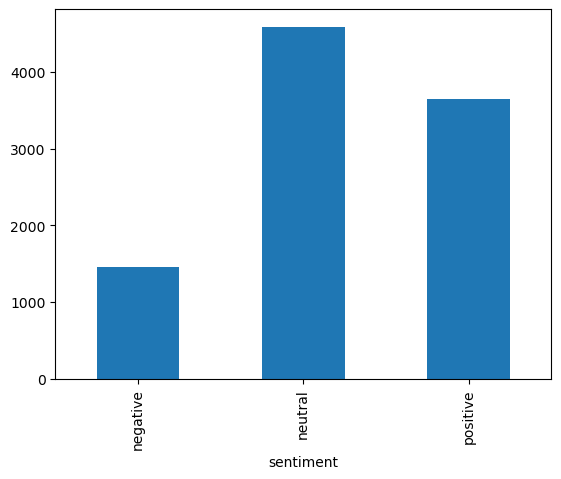

In [3]:
data.groupby('sentiment').size().plot(kind = 'bar')

In [4]:
print('Full data length:')
print(data.shape[0])

print('Unique tweets:')
print(data['text'].nunique())

Full data length:
9684
Unique tweets:
9649


### Tokens

The text must now be broken down into tokens. Each tokenizer has different rules for some more unusual cases, but roughly equates to separating out individual words. We will use a tweet specific tokenizer so that it can handle the specific tokens that are specific to social media.

In [5]:
from nltk.tokenize import TweetTokenizer

tt = TweetTokenizer()
# Example text
tweet = "This is a cooool #dummysmiley: :-) :-P <3 and some arrows < > -> <-- @remy: This is waaaaayyyy too much for you!!!!!!"
print(tt.tokenize(tweet))

['This', 'is', 'a', 'cooool', '#dummysmiley', ':', ':-)', ':-P', '<3', 'and', 'some', 'arrows', '<', '>', '->', '<--', '@remy', ':', 'This', 'is', 'waaaaayyyy', 'too', 'much', 'for', 'you', '!', '!', '!']


In [6]:
tweet = data['text'][4]
print(tt.tokenize(tweet))

['Tehran', '\\', 'u002c', 'Mon', 'Amour', ':', 'Obama', 'Tried', 'to', 'Establish', 'Ties', 'with', 'the', 'Mullahs', 'http://t.co/TZZzrrKa', 'via', '@PJMedia_com', 'No', 'Barack', 'Obama', '-', 'Vote', 'Mitt', 'Romney']


From these tokens, we can now extract certain information about each tweet e.g. the number of urls.

In [7]:
def url_count(row):
    count = 0
    tokens = tt.tokenize(row['text'])
    for token in tokens:
        if token.startswith('http'):
            count += 1
    return count

In [8]:
url_count(data.iloc[4])

1

In [9]:
data['url_count'] = data.apply(url_count, axis = 1)
data.head(5)

,id,sentiment,text,url_count
0,264183816548130816,positive,Gas by my house hit $3.39!!!! I\u2019m going t...,0
1,263405084770172928,negative,Theo Walcott is still shit\u002c watch Rafa an...,0
2,262163168678248449,negative,its not that I\u2019m a GSP fan\u002c i just h...,0
3,264249301910310912,negative,Iranian general says Israel\u2019s Iron Dome c...,0
4,262682041215234048,neutral,Tehran\u002c Mon Amour: Obama Tried to Establi...,1


<Axes: xlabel='url_count'>

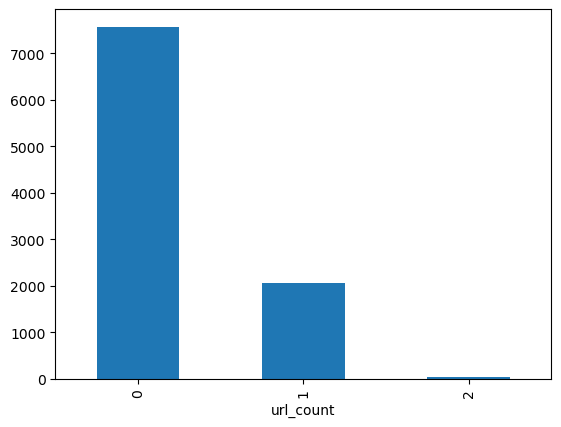

In [10]:
data.groupby('url_count').size().plot(kind = 'bar')

### Train-test split

Our end goal is to build a classifier and see how well it can classify the sentiment of different tweets. As a result, we want to use some data to train the classifier and also keep some data for testing. Sklearn helps us to do this.

The X value is the data that will be the input to our classifier model - here the text of the tweet. The y value is what the model should predict - here the sentiment of the tweet.

In [11]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size = 0.3)

In [12]:
X_train = train['text'].values
y_train = train['sentiment'].values
X_test = test['text'].values
y_test = test['sentiment'].values

## Bag-of-words and n-grams

We cannot just provide the text data as it is. Instead we need to convert them to a vector representation i.e. a series of numerical values. You have seen various options for doing this in the lectures.

### Bag-of-words

Bag-of-words counts how often each word appears in a text. This ignores both the order and the meaning. The assumption would be that similar documents have similar counts of each word. This can also be referred to as unigrams.

**fit**: Learn a vocabulary dictionary of all tokens in the raw documents.

**transform**: Transform documents to document-term matrix.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer() # initialize the vectorizer

In [14]:
# create the representation
vectorizer.fit(X_train)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [15]:
len(vectorizer.vocabulary_)

18711

In [16]:
bag_of_words = vectorizer.transform(X_train)
print('Bag-of-words dimensions:')
print(bag_of_words.shape)
print('Bag-of-words matrix:')
print(bag_of_words.toarray())

Bag-of-words dimensions:
(6778, 18711)
Bag-of-words matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


#### Bigrams

Rather than just looking at single words, now we will consider pairs of words. This means that some of the word order is being incorporated.

In [17]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigram_vectorizer.fit(X_train)
bigram_vectorizer.get_feature_names_out()

array(['00 11', '00 am', '00 argentina', ..., 'zumba tonight',
       'zurr08 will', 'zylona is'], dtype=object)

In [18]:
bigrams = bigram_vectorizer.transform(X_train).toarray()
bigrams.shape

(6778, 76816)

#### Unigrams and bigrams

We can also use both unigrams and bigrams together, increasing the number of possible combinations still further.

In [19]:
unibigram_vectorizer = CountVectorizer(ngram_range=(1, 2))
unibigram_vectorizer.fit(X_train)
uni_bigrams = unibigram_vectorizer.transform(X_train).toarray()
uni_bigrams.shape

(6778, 95527)

## Classification

Now we will build classifiers with these different vector representations. We can then compare the classifier model predictions for the test data to the correct values.

There are lots of possible models to use for classification, we will use logistic regression.

We start with the bag-of-words approach and train the model.

In [20]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(random_state=0)
clf = lg.fit(bag_of_words.toarray(), y_train)

Now to make predictions on the test data.

In [21]:
X_test_v = vectorizer.transform(X_test)
y_pred = clf.predict(X_test_v.toarray())

### Evaluation

First look at a few results.

In [22]:
pd.DataFrame([X_test[:5], y_pred[:5], y_test[:5]]).T

,0,1,2
0,I\u2019m going to Babaman at Vidia in Cesena\u...,neutral,neutral
1,Cool couch... Sep Kamvar\u002c Reid Hoffman\u0...,positive,positive
2,@_witnessMyrise uhmmm are you sure ? Cuz Groun...,neutral,neutral
3,@UConnVB wins the fourth set 25-21 to take the...,neutral,neutral
4,@PierceTehV3il_ how excited i was because dec ...,positive,negative


In [23]:
anti_tweet = "Ugh, this was true yesterday and it's also true now: Tom is an idiot"
clf.predict(vectorizer.transform([anti_tweet]))

array(['neutral'], dtype=object)

Sklearn has various functions for examining results.

In [24]:
from sklearn.metrics import classification_report # good for computing these metrics

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.57      0.38      0.45       451
     neutral       0.69      0.79      0.74      1400
    positive       0.69      0.65      0.67      1055

    accuracy                           0.68      2906
   macro avg       0.65      0.61      0.62      2906
weighted avg       0.67      0.68      0.67      2906



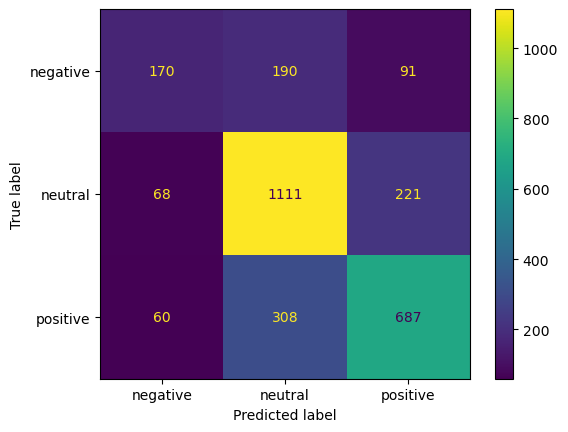

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot()

We will store these predictions for later.

In [26]:
results = {}
results['bow_sentiment'] = y_pred

### Compare methods

We can now repeat the process with the unigram and bigram combined vectorizer comparing the results.

In [27]:
lg = LogisticRegression(random_state=0)
clf = lg.fit(uni_bigrams, y_train)
X_test_v = unibigram_vectorizer.transform(X_test)
y_pred = clf.predict(X_test_v.toarray())
results['unibigram_sentiment'] = y_pred

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.60      0.32      0.41       451
     neutral       0.67      0.81      0.74      1400
    positive       0.69      0.64      0.66      1055

    accuracy                           0.67      2906
   macro avg       0.65      0.59      0.60      2906
weighted avg       0.67      0.67      0.66      2906



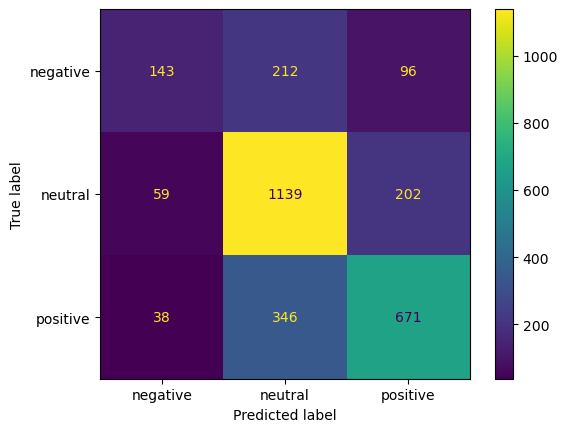

In [29]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot()

## Task 1

Whether only using unigrams or also incorporating bigrams, these models have similar performance. Try the same approach with TF-IDF and see if this is better able to classify.

## Task 2

Thus far we have vectorized the text data without pre-processing. Try creating a version of the data where all the tweets have any mentions (@) and urls removed. Use this data for a combined unigrams and bigrams representation to train a logistic regression model.

 _Hint: adapt the function that we used earlier to find urls_

## Word embeddings

Packages for word embeddings are no longer as well maintained. We have a [Google Colab Jupyter Notebook](https://colab.research.google.com/drive/1saTSEzYYTrgI_gzlcTmm0zjkD-7L3opL?usp=sharing) where you can try one out. You can create your own copy and will need to install gensim in Colab first.